In [67]:
import random
import numpy as np
import os

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

set_seed(42)


In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer
from torch.nn import Sequential, Embedding, Conv1d, AdaptiveMaxPool1d, Linear, Dropout, ReLU, Softmax, CrossEntropyLoss, Flatten
from torch.optim import Adam
from tqdm import tqdm
import torch




#  **Load the dataset (Kaggle dataset: emotions.csv)**


In [69]:
train_df = pd.read_csv("input/emotions-dataset-for-nlp/train.txt", sep=";", names=["text", "emotion"])
val_df   = pd.read_csv("input/emotions-dataset-for-nlp/val.txt", sep=";", names=["text", "emotion"])

# Combine train + val for full training set
df = pd.concat([train_df, val_df], ignore_index=True)

print(df.head())

                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


# 🔎 **Exploratory Data Analysis (EDA)**

Before training the CNN model, let's explore the dataset to better understand its structure, class distribution, and text properties.  

The main goals of this section are:
- Analyze the *distribution of emotions*.  
- Inspect the *length of sentences*.  
- Visualize *frequent words* using word clouds.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alexa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
C:\Users\alexa\AppData\Local\Temp\ipykernel_13540\501707124.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="emotion", data=df, order=df['emotion'].value_counts().index, palette="Set2")


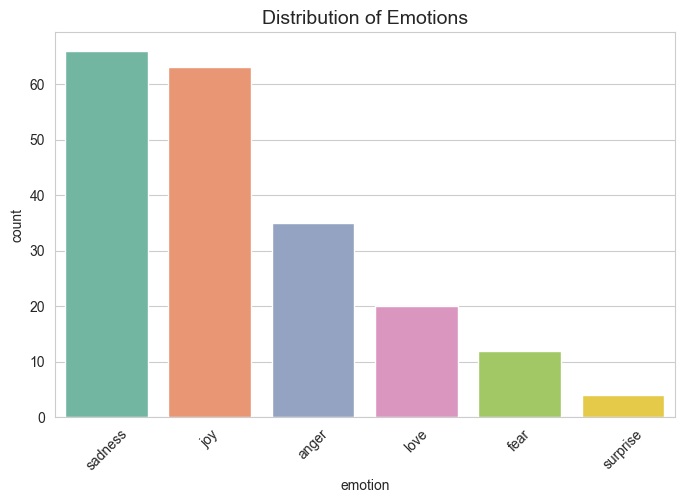

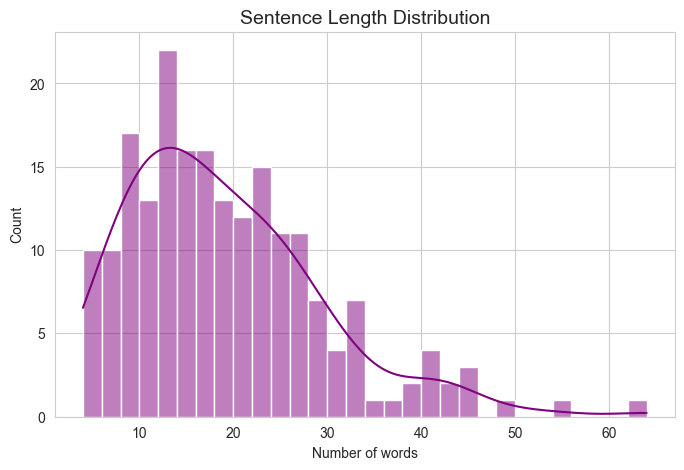

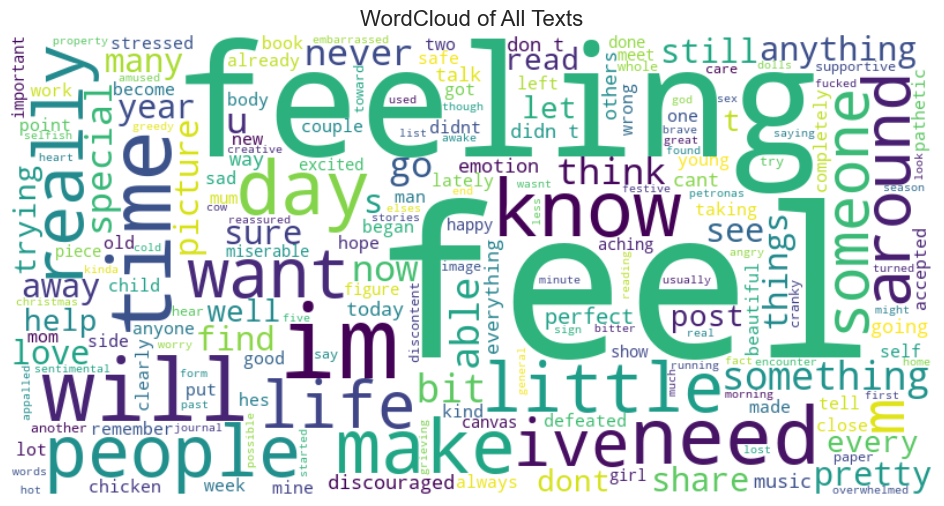

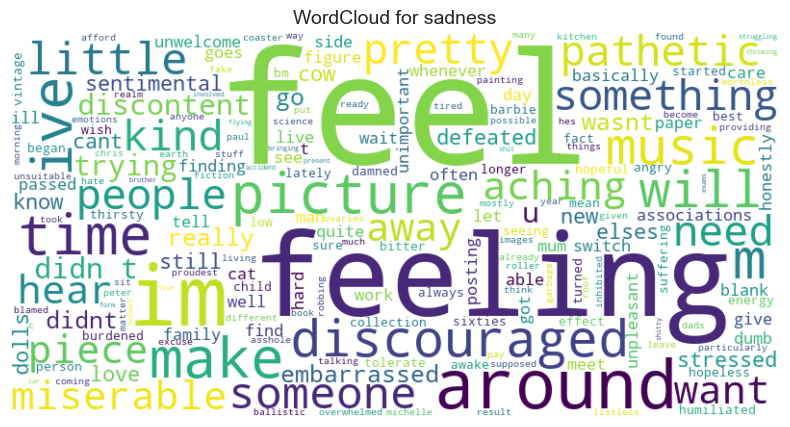

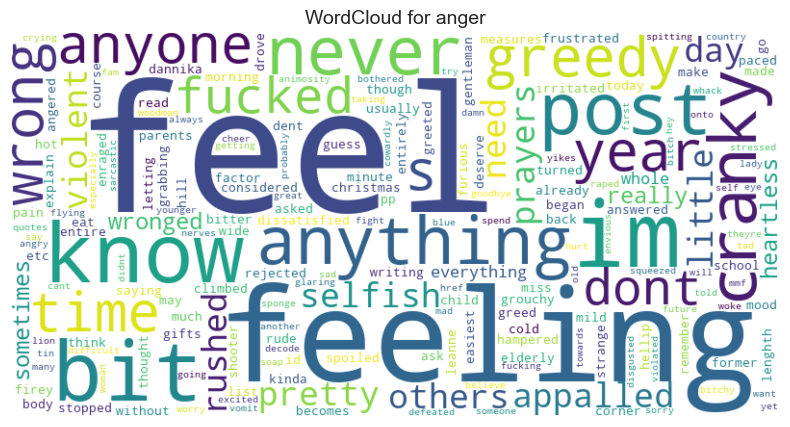

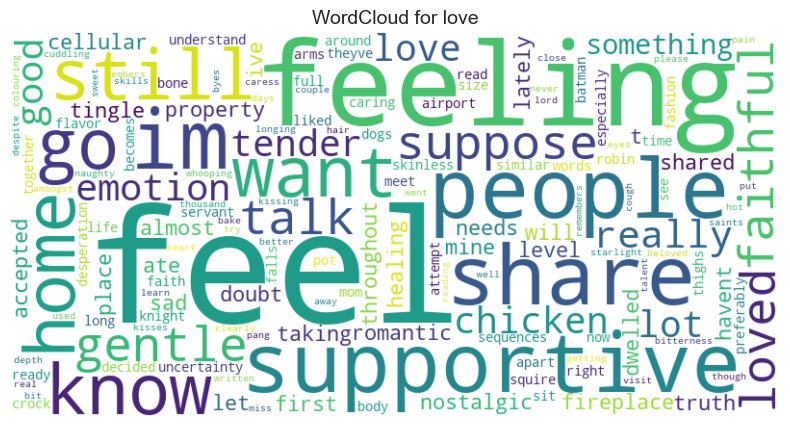

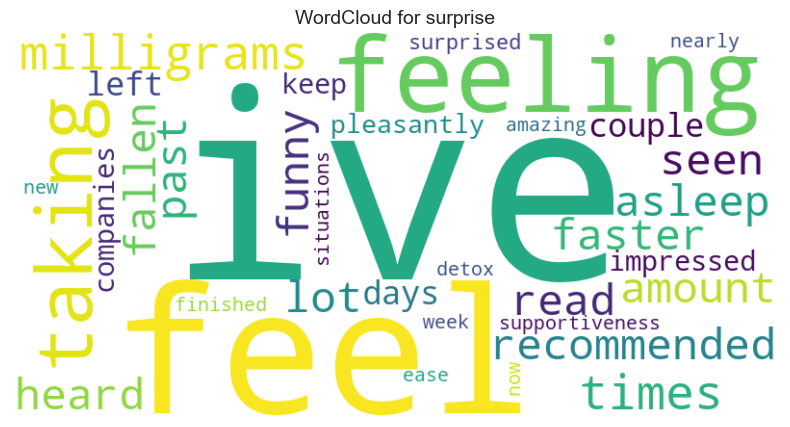

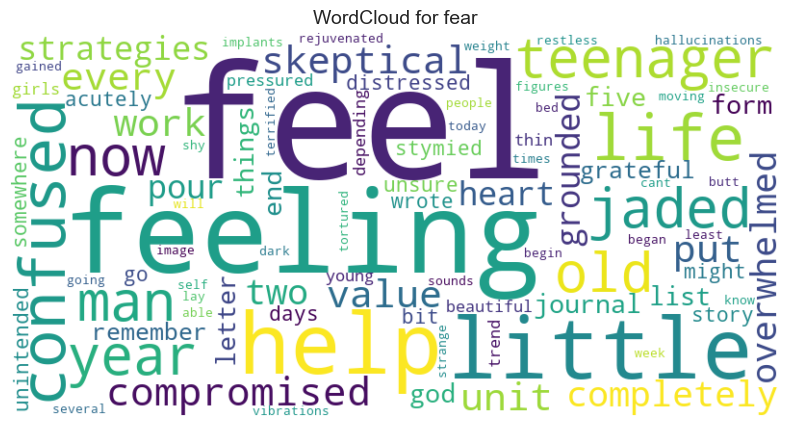

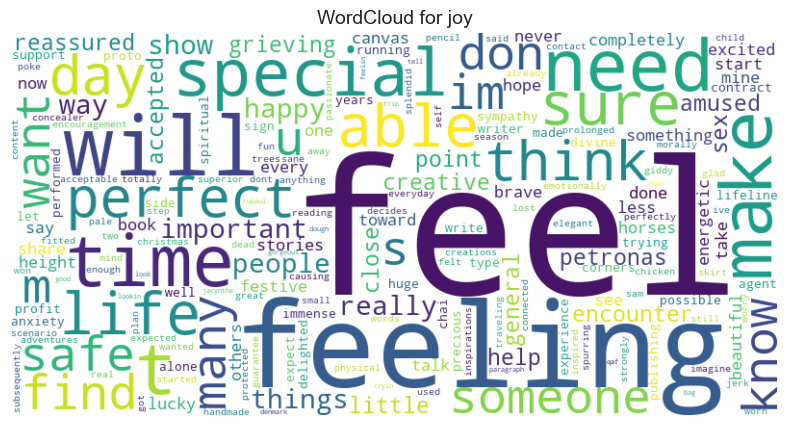

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize


#  Distribution of emotions
plt.figure(figsize=(8,5))
sns.countplot(x="emotion", data=df, order=df['emotion'].value_counts().index, palette="Set2")
plt.title("Distribution of Emotions", fontsize=14)
plt.xticks(rotation=45)
plt.show()

#  Sentence length analysis
df["sentence_length"] = df["text"].apply(lambda x: len(word_tokenize(str(x))))
plt.figure(figsize=(8,5))
sns.histplot(df["sentence_length"], bins=30, kde=True, color="purple")
plt.title("Sentence Length Distribution", fontsize=14)
plt.xlabel("Number of words")
plt.show()

#  WordCloud for all text
all_text = " ".join(df["text"].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of All Texts", fontsize=16)
plt.show()

#  WordCloud per emotion
emotions = df["emotion"].unique()
for emotion in emotions:
    text = " ".join(df[df["emotion"]==emotion]["text"].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {emotion}", fontsize=14)
    plt.show()

In [71]:
texts = df['text'].astype(str).tolist()
labels = df['emotion'].tolist()

#  **Encode the labels (convert emotions into integers)**


In [72]:
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

In [73]:
train_idx, val_idx = train_test_split(range(len(y)), test_size=0.2, random_state=42, stratify=y)

#  **Prepare text sequences**


In [74]:
max_words = 10000   # keep the top 10k most frequent words
max_len = 90       # maximum length of each text

tokenizer = BertTokenizer.from_pretrained("gaunernst/bert-mini-uncased", model_max_length=max_len)
X = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_len)

In [75]:
tokenizer

BertTokenizer(name_or_path='gaunernst/bert-mini-uncased', vocab_size=30522, model_max_length=90, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [76]:
import torch
from torch.utils.data import Dataset

class CustomBERTDataset(Dataset):
    def __init__(self, encodings, labels):
        # encodings: result of tokenizer(text, ...), likely a dictionary or BatchEncoding
        # labels: list or array of labels
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # 1. Get the data for the specific index 'idx'
        # We need to turn the dictionary of lists into a dictionary of single tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        
        # 2. Add the label
        item['labels'] = torch.tensor(self.labels[idx])
        
        return item

    def __len__(self):
        return len(self.labels)

In [77]:
dataset = CustomBERTDataset(X, y)

In [78]:
dataset.__getitem__(1)

C:\Users\alexa\AppData\Local\Temp\ipykernel_13540\1294147714.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


{'input_ids': tensor([  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
          9636, 17772,  2074,  2013,  2108,  2105,  2619,  2040, 14977,  1998,
          2003,  8300,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0,

In [79]:
train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=64, shuffle=True)

#  **Build CNN model**


In [82]:
from collections import OrderedDict

model = Sequential(
        OrderedDict([
        ("emb", Embedding(embedding_dim=66, num_embeddings=30522)),
        ("conv", Conv1d(in_channels=66, out_channels=128, kernel_size=5)),
        ("relu", ReLU()),
        ("maxpool", AdaptiveMaxPool1d(output_size=1)),
        ("flatten", Flatten()),
        ("relu", ReLU()),
        ("drop", Dropout(0.5)),
        ("linear", Linear(in_features = 128, out_features = len(encoder.classes_))),
        ("softmax", Softmax(dim=1))
    ])
)
optim = Adam(model.parameters())
criterion = CrossEntropyLoss()

#  **Train**


In [83]:
for epoch in range(5):
    total_train_loss = 0
    model.train()
    for batch in tqdm(train_loader):
        optim.zero_grad()
        inputs, labels = batch['input_ids'], batch['labels']
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optim.step()
        
        total_train_loss += loss.item()
    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    
    # 'torch.no_grad()' turns off gradient calculation. 
    # It saves massive amounts of memory and speeds up validation.
    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch['input_ids'], batch['labels']
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_val_loss += loss.item()
            
            # Calculate Accuracy (Optional but recommended)
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += (preds == labels).sum().item()
    
    # 3. Print Stats
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_predictions / len(val_idx)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

os.makedirs("output", exist_ok=True)
torch.save(model, "output/model.pt")


  0%|          | 0/3 [00:00<?, ?it/s]C:\Users\alexa\AppData\Local\Temp\ipykernel_13540\1294147714.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
100%|██████████| 3/3 [00:00<00:00, 45.21it/s]


Epoch 1 | Train Loss: 1.7764 | Val Loss: 1.7114 | Val Acc: 0.3250


100%|██████████| 3/3 [00:00<00:00, 51.83it/s]


Epoch 2 | Train Loss: 1.7283 | Val Loss: 1.7024 | Val Acc: 0.3250


100%|██████████| 3/3 [00:00<00:00, 53.42it/s]


Epoch 3 | Train Loss: 1.6677 | Val Loss: 1.6754 | Val Acc: 0.3250


100%|██████████| 3/3 [00:00<00:00, 48.19it/s]


Epoch 4 | Train Loss: 1.6669 | Val Loss: 1.6622 | Val Acc: 0.3500


100%|██████████| 3/3 [00:00<00:00, 38.75it/s]

Epoch 5 | Train Loss: 1.6507 | Val Loss: 1.6587 | Val Acc: 0.3250


In [84]:
tokenizer.save_pretrained("output/tokenizer")
torch.save(model, "output/model.pt")